In [13]:
# !pip install pytorchvideo transformers evaluate -q
# !pip install pytorchvideo torchvision==0.12.0
# !pip install evaluate

In [2]:
# pip install opencv-python


In [3]:
# !pip install --upgrade torch

In [4]:
# conda env list

In [ ]:
model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
#model_ckpt = "google/vivit-b-16x2-kinetics400"

batch_size = 4 # batch size for training and evaluation
from transformers import VideoMAEConfig, VideoMAEModel

# Initializing a VideoMAE videomae-base style configuration
configuration = VideoMAEConfig()

# Randomly initializing a model from the configuration
model = VideoMAEModel(configuration)

# Accessing the model configuration
configuration = model.config
print(configuration)

In [3]:
import pathlib

# Specify the dataset root path (make sure to define it beforehand)
#dataset_root_path = pathlib.Path('/kaggle/input/bdslw60-all-u1-u4-and-u8/BdSLW60_ALL')  # Change to your actual path
#output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/Datasets/not corrected 15%')
output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected')
output_root_path = pathlib.Path(r'previous/mini dataset 10 class out')
# Count videos in each set
video_count_train = len(list(output_root_path.glob("train/*/*.mp4")))
video_count_val = len(list(output_root_path.glob("val/*/*.mp4")))
video_count_test = len(list(output_root_path.glob("test/*/*.mp4")))

# Calculate total videos
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

# List all video file paths
all_video_file_paths = (
    list(output_root_path.glob("train/*/*.mp4")) +
    list(output_root_path.glob("val/*/*.mp4")) +
    list(output_root_path.glob("test/*/*.mp4"))
)

# Display the first five video file paths
print(all_video_file_paths[:5])

# Print total number of videos in each set and the first 5 video file paths for training
print(f"Total videos: {video_total}")
print(f"Training videos: {video_count_train}, Validation videos: {video_count_val}, Test videos: {video_count_test}")


Total videos: 126
[PosixPath('previous/mini dataset 10 class out/train/aids/U5W351F_trial_1.mp4'), PosixPath('previous/mini dataset 10 class out/train/aids/U3W351F_trial_1.mp4'), PosixPath('previous/mini dataset 10 class out/train/aids/U11W351F_trial_1.mp4'), PosixPath('previous/mini dataset 10 class out/train/aids/U15W351F_trial_1.mp4'), PosixPath('previous/mini dataset 10 class out/train/aids/U12W351F_trial_1.mp4')]
Total videos: 126
Training videos: 96, Validation videos: 10, Test videos: 20


In [4]:
# Adjust class label extraction logic
class_labels = sorted({str(path.parent.name) for path in all_video_file_paths})  # Use parent folder name as class label
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}
# Print the unique class labels and their mappings
print(f"Unique classes: {list(label2id.keys())}.")
print(f"Label to ID mapping: {label2id}")
#print(f"ID to Label mapping: {id2label}")

Unique classes: ['aalu', 'aam', 'aanarosh', 'aangur', 'aaple', 'aayna', 'ac', 'aids', 'apartment', 'attio'].
Label to ID mapping: {'aalu': 0, 'aam': 1, 'aanarosh': 2, 'aangur': 3, 'aaple': 4, 'aayna': 5, 'ac': 6, 'aids': 7, 'apartment': 8, 'attio': 9}


In [ ]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers import VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification

# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )

"""image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
model = TimesformerForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,)"""

image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

Pipeline Integration
# The relative quantization is integrated into the training transform pipeline:

UniformTemporalSubsample: Selects a fixed number of frames (num_frames_to_sample) from the video.
Lambda(lambda x: x / 255.0): Normalizes pixel values to [0, 1].
Lambda(relative_quantization): Applies relative quantization to the video frames.
Normalize(mean, std): Normalizes the frames based on predefined mean and standard deviation.
Resize(resize_to): Resizes frames to the target dimensions.

In [10]:
import torch
from torchvision.transforms import Lambda
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model configuration
model_ckpt = "MCG-NJU/videomae-base"
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)
config = VideoMAEConfig.from_pretrained(model_ckpt)
#model_ckpt = "google/vivit-b-16x2-kinetics400"
#config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
print(f"Number of frames to sample: {num_frames_to_sample}")
sample_rate = 8
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

import torch
from torchvision.transforms import Lambda

# Custom relative quantization function
def relative_quantization(frames, num_levels=16, threshold=0.1):
    """
    Dynamically quantizes video frames based on their differences from neighboring frames.
    Args:
        frames (Tensor): Video frames as a tensor of shape (T, C, H, W).
        num_levels (int): Base number of quantization levels. Default is 16.
        threshold (float): Sensitivity threshold for detecting changes between frames.
    Returns:
        Tensor: Quantized video frames.
    """
    # Ensure frames are normalized to [0, 1]
    frames = frames / 255.0 if frames.max() > 1 else frames
    T, C, H, W = frames.shape
    
    # Compute frame differences
    diffs = torch.abs(frames[1:] - frames[:-1]).mean(dim=(1, 2, 3))  # Mean absolute difference per frame
    
    # Adjust quantization levels based on differences
    dynamic_levels = torch.clamp((diffs / threshold).ceil() + num_levels, min=num_levels, max=256).int()
    
    quantized_frames = []
    for i in range(T):
        levels = dynamic_levels[i - 1] if i > 0 else num_levels  # Use previous frame's dynamic levels
        quantized_frame = torch.round(frames[i] * (levels - 1)) / (levels - 1)
        quantized_frames.append(quantized_frame)
    
    return torch.stack(quantized_frames, dim=0)

# Updated training dataset transformations with relative quantization
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Lambda(lambda x: relative_quantization(x, num_levels=16, threshold=0.1)),  # Apply relative quantization
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)
# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)               


Number of frames to sample: 16


In [ ]:
train_dataset.num_videos, val_dataset.num_videos, test_dataset.num_videos

In [12]:
# train data sample
sample_video = next(iter(train_dataset))
sample_video.keys()

dict_keys(['video', 'video_name', 'video_index', 'clip_index', 'aug_index', 'label'])

In [13]:
def investigate_video(sample_video):
    """Utility to investigate the keys present in a single video sample."""
    for k in sample_video:
        if k == "video":
            print(k, sample_video["video"].shape)
        else:
            print(k, sample_video[k])

    print(f"Video label: {id2label[sample_video[k]]}")

investigate_video(sample_video)

video torch.Size([3, 16, 224, 224])
video_name U12W2F_trial_4_R.mp4
video_index 1044
clip_index 0
aug_index 0
label 8
Video label: attio


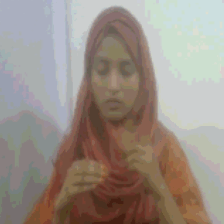

In [14]:
import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

video_tensor = sample_video["video"]
display_gif(video_tensor)
#print(video_tensor.shape)

In [15]:
import evaluate
metric = evaluate.load("accuracy")
import torch

def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions."""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)


def collate_fn(examples):
    """The collation function to be used by `Trainer` to prepare data batches."""
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
from huggingface_hub import login, hf_hub_download
# RnW token

# Authenticate using the API token
login(token=hf_token)

# Updated Training Loop

In [ ]:
import os
import torch
import logging
import matplotlib.pyplot as plt
import numpy as np
from transformers import Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
from transformers import EarlyStoppingCallback, AutoImageProcessor, VideoMAEForVideoClassification, VideoMAEImageProcessor
import seaborn as sns
import evaluate
from sklearn.metrics import classification_report
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

num_epochs = 20

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and image processor
model_ckpt = "MCG-NJU/videomae-base"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )
model.to(device)

# Output directory for checkpoints
output_checkpoint_dir = r"/media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_BdSLW60_FrameRate_Corrected_WIT_Augment_20_epoch_RQ_"
os.makedirs(output_checkpoint_dir, exist_ok=True)

# Plot confusion matrix
def plot_confusion_matrix(conf_matrix, class_labels, accuracy=None, dataset_name="Test Data", normalize=False, filename="confusion_matrix.png"):
    if normalize:
        conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    
    title = f"VideoMAE_BdSLW60 | {dataset_name} | Accuracy = {accuracy:.6f}" if accuracy is not None else f"VideoMAE_BdSLW60 | {dataset_name}"
    plt.title(title)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()

# Compute metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    # Calculate metrics
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted',zero_division=0)
    # Log metrics
    logging.info(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Accuracy: {accuracy:.4f}")
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Training arguments
#batch_size = 32
args = TrainingArguments(
    output_dir=output_checkpoint_dir,
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_ratio=0.1,
    logging_steps=100,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    load_best_model_at_end=True,
    max_steps=(train_dataset.num_videos // (2*4)) * num_epochs,  # Dynamically calculate max_steps
    report_to="none",
    fp16=True,
    weight_decay=0.01,
)

# Trainer initialization
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

# Train the model
trainer.train()
trainer.save_model()

# ------------------- TRAINING METRICS -------------------
train_predictions = trainer.predict(train_dataset)
train_preds = np.argmax(train_predictions.predictions, axis=1)
train_labels = train_predictions.label_ids

train_accuracy = accuracy_score(train_labels, train_preds)
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(train_labels, train_preds, average='weighted')

logging.info(f"Training Metrics - Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(train_labels, train_preds), 
    class_labels=list(id2label.values()), 
    accuracy=train_accuracy, 
    dataset_name=f"Train Data | P: {train_precision:.3f}, R: {train_recall:.3f}, F1: {train_f1:.3f}",
    filename="confusion_matrix_train100.png"
)

# ------------------- VALIDATION METRICS -------------------
val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=1)
val_labels = val_predictions.label_ids

val_accuracy = accuracy_score(val_labels, val_preds)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='weighted')

logging.info(f"Validation Metrics - Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(val_labels, val_preds), 
    class_labels=list(id2label.values()), 
    accuracy=val_accuracy, 
    dataset_name=f"Valid Data | P: {val_precision:.3f}, R: {val_recall:.3f}, F1: {val_f1:.3f}",
    filename="confusion_matrix_valid100.png"
)

# ------------------- TEST METRICS -------------------
test_predictions = trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=1)
test_labels = test_predictions.label_ids

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted')

logging.info(f"Test Metrics - Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(test_labels, test_preds), 
    class_labels=list(id2label.values()), 
    accuracy=test_accuracy, 
    dataset_name=f"Test Data | P: {test_precision:.3f}, R: {test_recall:.3f}, F1: {test_f1:.3f}",
    filename="confusion_matrix_test100.png"
)

# Calculate metrics for the test dataset
test_results = {
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
}

# Log and save metrics
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
trainer.save_state()
trainer.push_to_hub()

logging.info(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
print(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
